# Calibration: Theory and Implementation

Since we are building a programmable mesh, that implements a unitary transformation, we have to calibrate our mesh (represented by physical models) to match the physical components to the theoretical components. This notebook explains the theory of each calibration implemented and the associated programming and physical description.

### Imports & Functions

In [1]:
import multiport_interferometer as mi
import numpy as np
import matplotlib.pyplot as plt
import sax
from scipy.stats import unitary_group, ortho_group

In [2]:
def plot_matrix_errors(targets, results):
    targets = np.asarray(targets)
    results = np.asarray(results)
    mag_error = np.abs(results)-np.abs(targets)
    phase_error = np.angle(results/targets, deg=True)
    n = targets.shape[1]
    plt.figure()
    for i in range(n):
        for j in range(n):
            plt.plot(mag_error[:, i, j], label=f"({i},{j})")
    plt.xlabel("Matrix index")
    plt.ylabel("Magnitude error")
    plt.legend()
    plt.grid()
    plt.show()
    plt.figure()
    for i in range(n):
        for j in range(n):
            plt.plot(phase_error[:, i, j], label=f"({i},{j})")
    plt.xlabel("Matrix index")
    plt.ylabel("Phase error (degrees)")
    plt.legend()
    plt.grid()
    plt.show()

def plot_errors(targets, results):
    dims = []
    mag_errors = []
    phase_errors = []

    for T, R in zip(targets, results):
        T = np.asarray(T)
        R = np.asarray(R)
        dims.append(T.shape[0])
        phi_global = np.angle(np.vdot(T,R))
        R = R * np.exp(-1j * phi_global)
        mag_error = np.abs(np.abs(R)-np.abs(T))*100/np.abs(T)
        phase_error = np.abs(np.angle(R*np.conj(T), deg=True))*100/180
        mag_errors.append(np.mean(mag_error))
        phase_errors.append(np.mean(phase_error))
    plt.figure()
    plt.plot(dims, mag_errors, 'o-', label="Magnitude error")
    plt.plot(dims, phase_errors, 'o-', label="Phase error")
    plt.xlabel("Matrix dimension")
    plt.ylabel("Average error (%)")
    plt.legend()
    plt.grid()
    plt.show()

## MZI State Calibration

### Delta Bias

Mathematically the decomposition from bell_decomposer, which is based on the Strawberry Fields library, breaks down the Bell type mesh into the components with the MZI mathematically represented using the standard Beam Splitter Convention where the transfer matrix of the mzi is:
$$M = e^{i\Sigma}\begin{pmatrix}sin\delta &cos\delta \\ cos\delta &-sin\delta\end{pmatrix}$$

and $\Sigma = (\theta_1 + \theta_2)/2$ and $\delta = (\theta_1 - \theta_2)/2$ where $\theta$ are the internal phases of the two mzi arms respectively.

My mzi model defined in the models file is based on the fdtd simulations of the directional coupler and phase shifters (from the Simulations notebook) put together into an MZI using a Sax circuit which includes the extra programmed phase into the phase shfiters.

We can view the default transfer matrix of our MZI by calling the model with no extra programmed phase:

In [3]:
mzm_matrix = mi.sdict_to_matrix(mi.mzi_model())
print('MZI Magnitude:')
print(np.round(abs(mzm_matrix),6))
print()
print('MZI phases:')
print(np.round(np.angle(mzm_matrix),6))

MZI Magnitude:
[[0.07869  0.98888 ]
 [0.988898 0.078574]]

MZI phases:
[[-0.356178 -0.460666]
 [-0.411827  2.625148]]


The theoretical MZI has default state ($\theta_1 = \theta_2 = 0$) $$M_0 = \begin{pmatrix}0&1\\1&0\end{pmatrix}$$

This is nearly true for out physical model. To Calibrate our mzi into it's complete cross state we need to apply a bias to the delta variable. We find the delta bias using the following delta sweep:

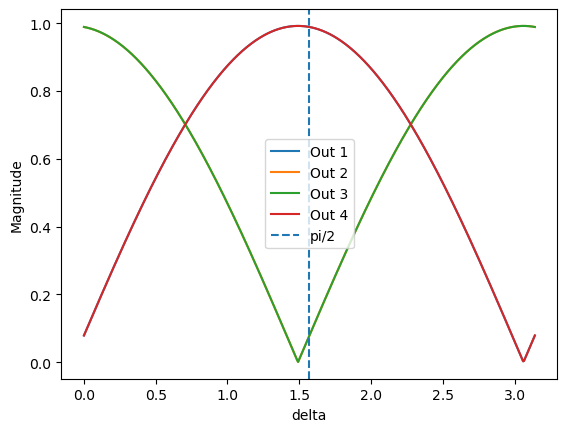

In [4]:
deltas = np.linspace(0,np.pi, 500)
out1 = []
out2 = []
out3 = []
out4 = []
for delt in deltas:
    mzm = mi.mzi_model(delta=delt)
    mzm=mi.sdict_to_matrix(mzm)
    out1.append(abs(mzm[0,0]))
    out2.append(abs(mzm[0,1]))
    out3.append(abs(mzm[1,0]))
    out4.append(abs(mzm[1,1]))
plt.plot(deltas, out1, label='Out 1')
plt.plot(deltas, out2, label='Out 2')
plt.plot(deltas, out3, label='Out 3')
plt.plot(deltas, out4, label='Out 4')
plt.axvline(x=np.pi/2, linestyle='--', label='pi/2')
plt.ylabel('Magnitude')
plt.xlabel('delta')
plt.legend()

This graph shows how the power oscillates between the output ports as the phase differential is sweeped. In the completely passive state with no thermal phase shifter activation the mzi is not exactly in the cross state. This is because the directional couplers are close to but not ideal. In the ideal case the mzi is by default in cross state. For our mzi to be in cross state we need a bias that is just below zero or alternatively slightly below $\pi$. We find it as the delta value that maximizes the anti-diagonal out 2 and out 3.

In [13]:
maxindex= out3.index(max(out3))
print("Delta correction:",deltas[maxindex])

Delta correction: 3.0597475543980748


In [5]:
mzm_matrix = mi.sdict_to_matrix(mi.mzi_model(delta=3.0629742188152735))
print('MZI Magnitude:')
print(np.round(abs(mzm_matrix),6))
print()
print('MZI phases:')
print(np.round(np.angle(mzm_matrix),6))

MZI Magnitude:
[[7.84000e-04 9.92001e-01]
 [9.92019e-01 6.70000e-04]]

MZI phases:
[[ 2.857315  2.680926]
 [ 2.729766 -0.61563 ]]


In the models file we define a new mzi model which uses the physical representation mzi_model but adds onto it this delta bias to achieve a calibrated mzi. The function calibrated_mzi_model also contains a sigma bias explained below

### Sigma Bias

In our mesh we are using physical models for all components (from fdtd simulations) that include all the static phase accumulation across paths. The optical path of light in the unmodulated mzi should be equal to that through the plain waveguide and unmodulated phase shifter components. The gds components were designed to have the same physical path lengths, however in reality, the light through the MZI passes through 2 directional couplers where it travels as a supermode, with refractive index and optical length different than one single waveguide core. To match the optical length, the waveguide component can be optimised so that the pahse accumulation is the same as the MZI. Alternatively, since the MZI is tunable, this project tunes the MZI static phase accumulation to match the plain waveguide component. This is done my modulating the Sigma variable, which changes the total phase of the MZI function. Mathematically the physical matrix $M_p$ is $$M_p = e^{i\Sigma}M_i$$ where $M_i$ is the ideal transfer matrix. The following code finds the sigma bias required to calibrate the MZI:

In [4]:
Mideal = mi.sdict_to_matrix(mi.ideal_mzi(0, 0))
Mp = mi.sdict_to_matrix(mi.mzi_model(delta=+3.0629742188152735))
plain_phase = np.angle(mi.plain_wvgd_model()[('in0','out0')])
phase_shifter_phase = np.angle(mi.phase_shifter_model()[('in0','out0')])
gamma = np.angle(np.vdot(Mideal, Mp)) #phase difference between ideal mzi and my model
print(gamma)
print(plain_phase, phase_shifter_phase)
print('Required sigma correction:',(plain_phase-gamma)%np.pi)

2.7053459166803573
[-1.54018263] [-1.54018263]
Required sigma correction: [2.03765676]


The function calibrated_mzi_model contains the delta and sigma calibrations and is used in the mesh.

In [5]:
mzm_matrix = mi.sdict_to_matrix(mi.calibrated_mzi_model())
print('MZI Magnitude:')
print(np.round(abs(mzm_matrix),6))
print()
print('MZI phases:')
print(np.round(np.angle(mzm_matrix),6))

MZI Magnitude:
[[7.84000e-04 9.92001e-01]
 [9.92019e-01 6.70000e-04]]

MZI phases:
[[-1.388213 -1.564603]
 [-1.515763  1.422026]]


For a real physical implementation, characterization must be done on fabricated mzis to build a physical model. Then similar calibration steps would be taken to calibrate the mzi, but using experimentaly derived physical models rather than the fdtd model.

## Validating Complete Mesh
what follows are some tests to evaluate the behaviour of the photonic interferrometer mesh.

Since all the models account for static phase accumulation for all components, it is expected that the final resulting tranfer matrix will contain a global phase offset from the desired one. We find this offset by finding the angle of the Frobenius inner product between the target and simulation matrices. For accuracy we find the average angle over 20 random target unitary matrices

In [6]:
U_targets=[]
S_results = []
dim=3
mymesh = mi.Bell(dim)
for i in range(20):
    U = unitary_group(dim=dim).rvs()
    U_targets.append(U)
    S = mymesh.emulate(U)
    S_mat = mi.sdict_to_matrix(S)
    S_results.append(S_mat)

In [7]:
overlap = sum(np.vdot(T, R) for T, R in zip(U_targets, S_results))
phi_global = np.angle(overlap)
print("Global Phase offset",np.degrees(phi_global))

Global Phase offset 116.01802176853079


Now we can obtain a mesh that emulates a target unitary to high precision

In [9]:
dimension = 3
test_bell = mi.Bell(dimension)
U_target = unitary_group(dim=dimension).rvs()

S = test_bell.emulate(U_target)
S_mat = mi.sdict_to_matrix(S)*np.exp(-1j*phi_global) #Applying global phase correction
print('Target Magnitude')
print(abs(U_target))
print('Physical Simulation Magnitude')
print(abs(S_mat))
print('Magnitude Relative Error %')
print((abs(abs(S_mat)-abs(U_target)))*100/abs(S_mat))
print('Target Phase')
print(np.angle(U_target))
print("SImulation Phase (Global Phase Removed)")
print(np.angle(S_mat))
print('phase error %')
print(np.angle(S_mat/U_target)*100/np.pi) #maximum possible phase error is pi

Target Magnitude
[[0.27637824 0.3396685  0.8990219 ]
 [0.94274542 0.25323291 0.21703496]
 [0.18667122 0.90581367 0.38033597]]
Physical Simulation Magnitude
[[0.27384691 0.32769192 0.87432918]
 [0.91575215 0.2516384  0.2116996 ]
 [0.18222628 0.88098805 0.37063312]]
Magnitude Relative Error %
[[0.92436073 3.65482914 2.82419068]
 [2.94766076 0.63365028 2.52025102]
 [2.43924467 2.81792902 2.61791031]]
Target Phase
[[ 0.63557363  2.89417031 -1.06562414]
 [ 0.49394881 -0.98024151  2.18258584]
 [ 2.11538353 -2.81500111  2.76899639]]
SImulation Phase (Global Phase Removed)
[[ 0.77943571  2.86548448 -1.11441441]
 [ 0.59844428 -1.00089037  2.078587  ]
 [ 2.16424702 -2.86986778  2.68953041]]
phase error %
[[ 4.57927226 -0.91309821 -1.55304272]
 [ 3.32619439 -0.65727378 -3.31038614]
 [ 1.55537288 -1.74646023 -2.52948091]]


Note that in reality this mathematica global phase is irrelevant, however it is usefull to remove it in order to evaluate out mesh.

As is clear the photonic interferrometer mesh behaves as the desired unitary up with high accuracy. The differences are attributed to the physical losses and slight phase offsets of the physical components fdtd simulations.

### Errors across dimension sweep
what follows is a sweep across matrix/mesh dimension and plotting of the average phase and magnitude errors

In [5]:
U_targets=[]
S_results = []
for dimension in range(2,20):
    U = unitary_group(dim=dimension).rvs()
    interferometer = mi.Bell(dimension)
    S = interferometer.emulate(U)
    S_mat = mi.sdict_to_matrix(S)
    S_results.append(S_mat)
    U_targets.append(U)

The following plots the average Magnitude and Phase errors as a percentage. The function plot_errors computes the error for each matrix element and then takes the mean of the error matrix. This way matrices of different dimensions can be compared. Phase error percent is a fraction of $180^\circ$ because phase is circular and the maximum possible phase error is $180^\circ$.

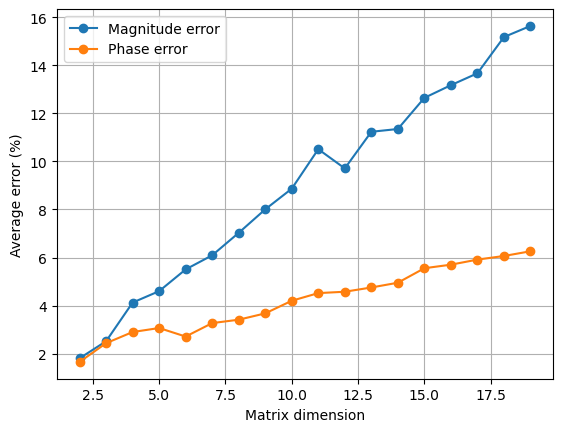

In [6]:
plot_errors(U_targets,S_results)

Up to dimension 20 the physical mesh emulates the desired unitary very well with average magnitude errors less than 20% and average phase errors less that 10%.

The errors accumulate as the dimension increases. This is expected given that the number of componenets increases and the small phase and transmission deviations from each component add up.

### The purpose of this notebook is calibration, and as far as that is concerned the physical mesh has been successfully calibrated.